размер: (400, 600)


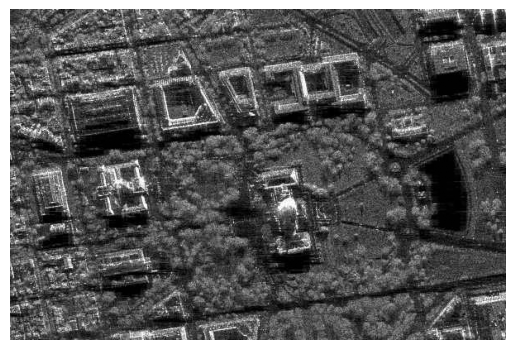

In [9]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. \n"
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

image_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

if image_gray is None:
    print("не загрузилось изображение. проверить имя файла.")
else:
    print(f"размер: {image_gray.shape}")
    plt.imshow(image_gray, cmap='gray')
    plt.axis('off')
    plt.show()

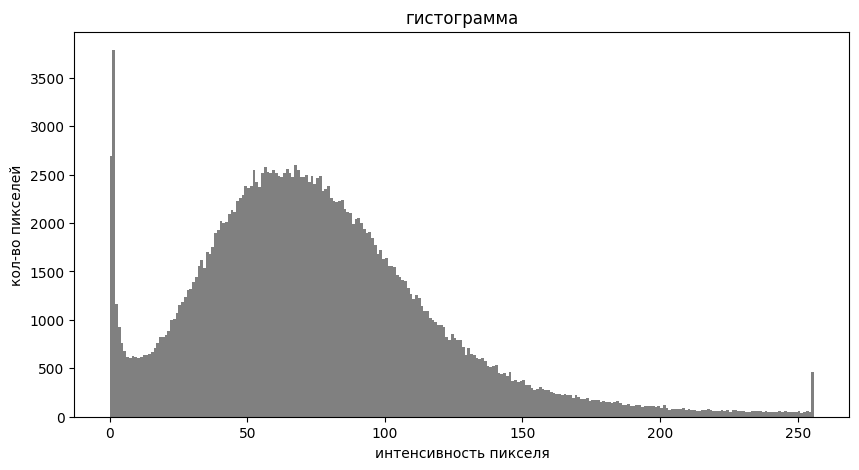

In [10]:
# гистограмма
plt.figure(figsize=(10, 5))
plt.hist(image_gray.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('гистограмма')
plt.xlabel('интенсивность пикселя')
plt.ylabel('кол-во пикселей')
plt.show()

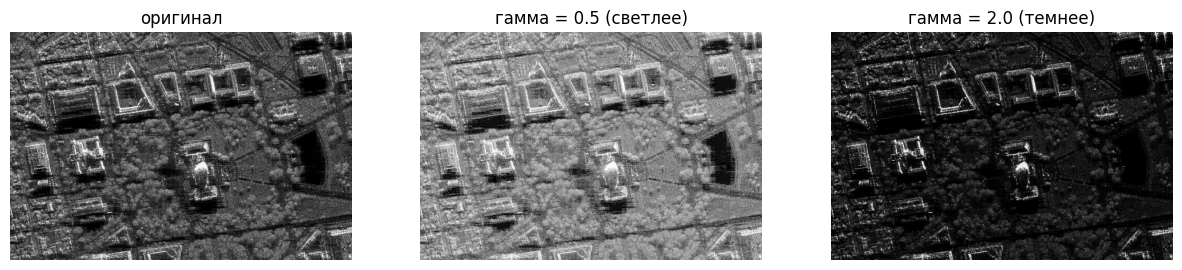

In [11]:
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
def gamma_correction(image, gamma):
    normalized = image / 255.0
    corrected = np.power(normalized, gamma) # формула
    return np.uint8(corrected * 255)

# гамма-коррекция
gamma_low = 0.5  # гамма < 1 (осветляет)
gamma_high = 2.0 # гамма > 1 (затемняет)

img_gamma_low = gamma_correction(image_gray, gamma_low)
img_gamma_high = gamma_correction(image_gray, gamma_high)

# визуализ
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("оригинал")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gamma_low, cmap='gray')
plt.title(f"гамма = {gamma_low} (светлее)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_gamma_high, cmap='gray')
plt.title(f"гамма = {gamma_high} (темнее)")
plt.axis('off')

plt.show()

In [12]:
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

mse_low = mse(image_gray, img_gamma_low)
ssim_low = ssim(image_gray, img_gamma_low)

mse_high = mse(image_gray, img_gamma_high)
ssim_high = ssim(image_gray, img_gamma_high)

print(f"1. оригинал vs гамма {gamma_low}:")
print(f"MSE: {mse_low:.2f}")
print(f"SSIM: {ssim_low:.4f}")
print(" ")
print(f"2. оригинал vs гамма {gamma_high}:")
print(f"MSE: {mse_high:.2f}")
print(f"SSIM: {ssim_high:.4f}")

1. оригинал vs гамма 0.5:
MSE: 3250.43
SSIM: 0.7875
 
2. оригинал vs гамма 2.0:
MSE: 2383.76
SSIM: 0.5270


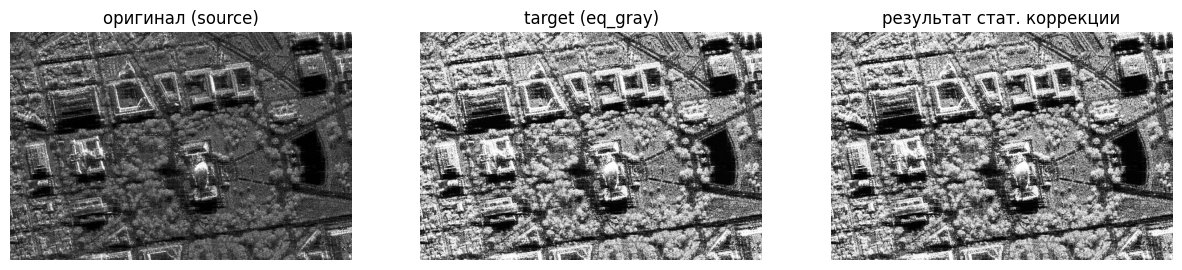

In [13]:
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.

target_img = cv2.equalizeHist(image_gray)

def statistical_color_correction(source, target):

    mean_s = np.mean(source)
    std_s = np.std(source)

    mean_t = np.mean(target)
    std_t = np.std(target)

    corrected = mean_s + (target.astype(np.float32) - mean_t) * (std_s / std_t)
    return np.uint8(np.clip(corrected, 0, 255))


img_stat_corrected = statistical_color_correction(image_gray, target_img)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("оригинал (source)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(target_img, cmap='gray')
plt.title("target (eq_gray)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_stat_corrected, cmap='gray')
plt.title("результат стат. коррекции")
plt.axis('off')
plt.show()

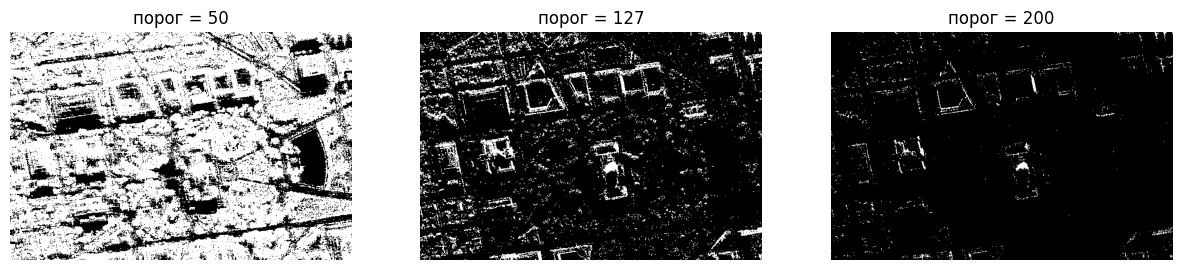

In [14]:
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

# разные значения порога
thresholds = [50, 127, 200]

plt.figure(figsize=(15, 5))

for i, t in enumerate(thresholds):
    # бинаризация
    _, binary_img = cv2.threshold(image_gray, t, 255, cv2.THRESH_BINARY)

    plt.subplot(1, 3, i+1)
    plt.imshow(binary_img, cmap='gray')
    plt.title(f"порог = {t}")
    plt.axis('off')

plt.show()